In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [29]:
df = pd.read_csv("placement.csv")

In [30]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [32]:
df.shape

(100, 4)

In [33]:
df.isna().sum()

Unnamed: 0    0
cgpa          0
iq            0
placement     0
dtype: int64

In [34]:
df = df.iloc[ : , 1: ]

In [35]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


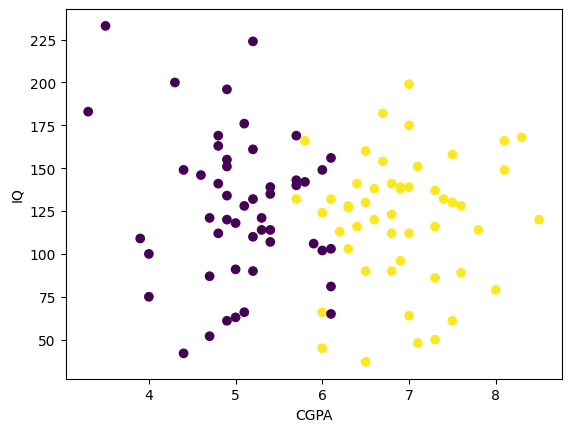

In [40]:
plt.scatter(df["cgpa"], df["iq"], c=df["placement"])
plt.xlabel("CGPA")
plt.ylabel("IQ")
plt.show()

In [51]:
x = df.iloc[:, 0:2]
y = df.iloc[:, 2:]

In [52]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [53]:
x

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [61]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.1)

In [63]:
X_train

,cgpa,iq
61,7.3,137.0
46,5.3,114.0
36,5.7,140.0
17,3.3,183.0
41,5.4,114.0
...,...,...
97,6.7,182.0
95,4.3,200.0
68,4.0,75.0
15,5.1,176.0


In [64]:
y_train

,placement
61,1
46,0
36,0
17,0
41,0
...,...
97,1
95,0
68,0
15,0


In [65]:
X_test

,cgpa,iq
50,3.5,233.0
77,7.3,50.0
29,7.0,112.0
55,7.8,114.0
44,7.5,61.0
32,7.0,139.0
65,8.1,166.0
11,6.9,138.0
60,6.9,139.0
23,4.7,87.0


In [66]:
from sklearn.preprocessing import StandardScaler

In [67]:
scaler = StandardScaler()

In [68]:
X_train = scaler.fit_transform(X_train)

In [69]:
X_train

array([[ 1.27750599,  0.35053993],
       [-0.56800828, -0.24864889],
       [-0.19890543,  0.428695  ],
       [-2.41352256,  1.54891757],
       [-0.47573257, -0.24864889],
       [ 1.00067885,  1.34050407],
       [ 1.00067885,  1.96574457],
       [ 0.81612742, -0.87388939],
       [ 0.44702457, -0.19654551],
       [ 0.81612742, -0.0141837 ],
       [ 0.17019743, -0.53521745],
       [-0.93711114,  0.71526356],
       [-0.84483542, -1.57728496],
       [-0.75255971, -1.4991299 ],
       [ 1.27750599, -0.19654551],
       [ 2.0157117 ,  0.66316019],
       [ 2.20026313,  1.15814225],
       [-1.85986828, -0.37890733],
       [-1.21393828,  0.58500512],
       [ 0.17019743,  0.845522  ],
       [ 0.07792171,  0.66316019],
       [ 1.09295457,  0.71526356],
       [ 1.27750599, -0.97809614],
       [-0.84483542, -0.84783771],
       [-0.75255971,  0.11607474],
       [-0.84483542, -0.14444214],
       [ 0.35474886,  0.11607474],
       [-1.12166257, -1.86385353],
       [ 1.46205742,

In [70]:
X_test = scaler.transform(X_test)

In [71]:
X_test

array([[-2.22897113,  2.85150196],
       [ 1.27750599, -1.9159569 ],
       [ 1.00067885, -0.30075226],
       [ 1.73888456, -0.24864889],
       [ 1.46205742, -1.62938834],
       [ 1.00067885,  0.40264331],
       [ 2.0157117 ,  1.10603888],
       [ 0.90840314,  0.37659162],
       [ 0.90840314,  0.40264331],
       [-1.12166257, -0.95204446]])

In [72]:
from sklearn.linear_model import LogisticRegression

In [73]:
clf = LogisticRegression()

In [75]:
clf.fit(X_train, y_train)

C:\Users\user\Desktop\New folder\AI\venv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [78]:
y_pred = clf.predict(X_test)

In [79]:
y_test

,placement
50,0
77,1
29,1
55,1
44,1
32,1
65,1
11,1
60,1
23,0


In [81]:
from sklearn.metrics import accuracy_score

In [82]:
accuracy_score(y_test, y_pred)

1.0

In [89]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

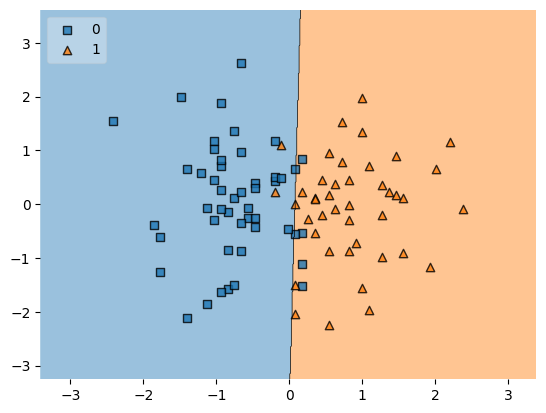

In [91]:
plot_decision_regions(X_train, y_train.values.ravel(), clf=clf, legend=2)

In [92]:
import pickle

In [94]:
pickle.dump(clf, open("model.pkl", "wb"))